## Плотникова Вероника и Отыргашева Мила

- - -

### Задание 1. Загрузка данных

Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Загрузка датасета

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- - -

### Задание 2

Определение количества строк и столбцов

In [4]:
df.shape

(891, 12)

Названия столбцов

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Типы данных

In [7]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

- - -

### Задание 3. Анализ пассажиров по:

1) количество по классам

In [9]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

2) полу

In [11]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

3) возрастным группам

In [12]:
bins = [0, 13, 20, 36, 60, 100]
labels = ['Ребенок', 'Подросток', 'Молодой взрослый', 'Взрослый', 'Пожилой']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
df['AgeGroup'].value_counts()

AgeGroup
Молодой взрослый    333
Взрослый            191
Подросток            95
Ребенок              69
Пожилой              26
Name: count, dtype: int64

4) расчет среднего возраста

In [13]:
df['Age'].mean()

29.69911764705882

5) расчет медианного возраста

In [14]:
df['Age'].median()

28.0

 6) расчет средней стоимости билета

In [15]:
df['Fare'].mean()

32.204207968574636

- - -

### Задание 4. Сравнение пассажиров разных классов

Сравнение характеристик пассажиров в зависимости от класса обслуживания.

In [16]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [17]:
df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [18]:
pd.crosstab(df['Pclass'], df['Sex'])

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


In [19]:
df['Pclass'].value_counts().idxmax()

3

In [28]:
df.loc[df['Fare'].idxmax(), ['Pclass', 'Age', 'Sex', 'Survived']]

Pclass           1
Age           35.0
Sex         female
Survived         1
Name: 258, dtype: object

Вывод: Пассажиры 1-го класса платили значительно больше за билет и были в среднем старше.

- - -

### Задание 5. Анализ выживаемости пассажиров в целом, в разрезе пола и класса.

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [21]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [22]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean()

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

In [23]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().idxmax()

(1, 'female')

Вывод: Наибольшую долю выживших имели женщины из 1-го класса.

- - -

### Задание 6. Визуализация распределения пассажиров по классам и выживаемости по полу.

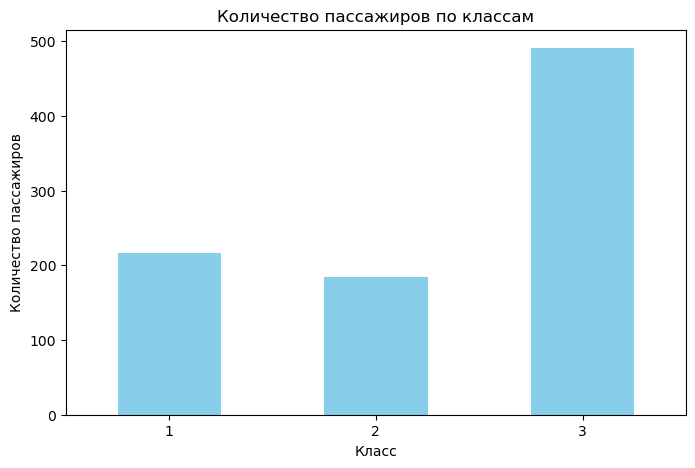

In [24]:
plt.figure(figsize=(8, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Количество пассажиров по классам')
plt.xlabel('Класс')
plt.ylabel('Количество пассажиров')
plt.xticks(rotation=0)
plt.show()

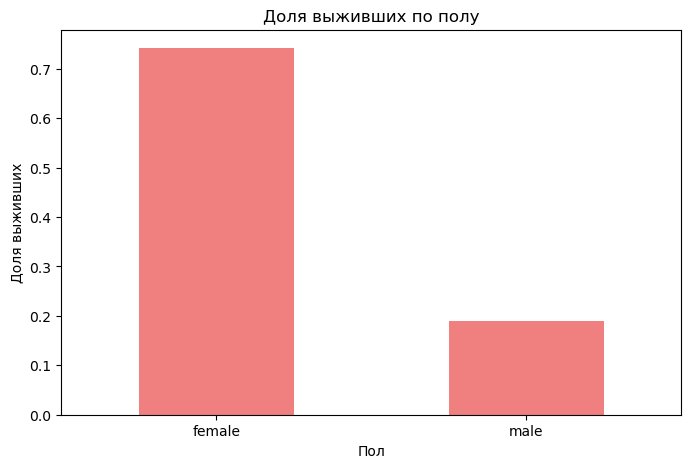

In [25]:
plt.figure(figsize=(8, 5))
survival_by_sex = df.groupby('Sex')['Survived'].mean()
survival_by_sex.plot(kind='bar', color='lightcoral')
plt.title('Доля выживших по полу')
plt.xlabel('Пол')
plt.ylabel('Доля выживших')
plt.xticks(rotation=0)
plt.show()

### Собственный вопрос:

Влияет ли наличие родственников на борту на вероятность выживания?

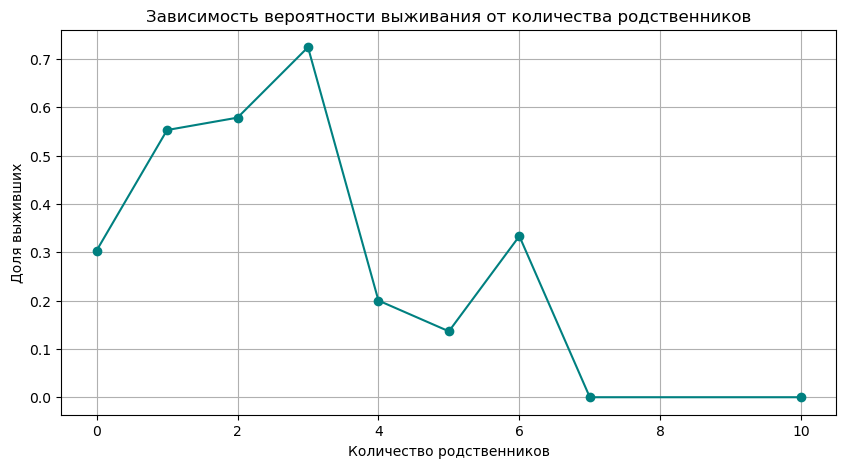

In [27]:
df['Relatives'] = df['SibSp'] + df['Parch']
plt.figure(figsize=(10, 5))
df.groupby('Relatives')['Survived'].mean().plot(kind='line', marker='o', color='teal')
plt.title('Зависимость вероятности выживания от количества родственников')
plt.xlabel('Количество родственников')
plt.ylabel('Доля выживших')
plt.grid(True)
plt.show()

Вывод: Пассажиры с небольшим количеством родственников имели более высокие шансы на выживание по сравнению с теми, кто путешествовал в одиночку или с очень большими семьями (более 3 человек)